In [1]:
print("hello")

hello


========== ORIGINAL DATA ==========
   Customer_ID           Name   Age  Gender       City     Income  \
0         1001  Karthik Patel  20.0  Female    Kolkata   809351.0   
1         1002   Mohan Kapoor  54.0  Female        NaN   743216.0   
2         1003    Suresh Nair  60.0    Male      Delhi   932405.0   
3         1004      Mohan Raj  57.0    Male  Hyderabad  1083550.0   
4         1005    Karthik Das  43.0  Female    Kolkata  1383279.0   

   Purchase_Frequency  Total_Spending  Customer_Satisfaction  
0                   4           94524                    5.0  
1                  13           86006                    1.0  
2                  13           29704                    4.0  
3                  10           99913                    2.0  
4                  18           99108                    1.0  

Dataset Shape:
(1020, 9)

========== DATA INFORMATION ==========
<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 9 columns):
 #   Colum

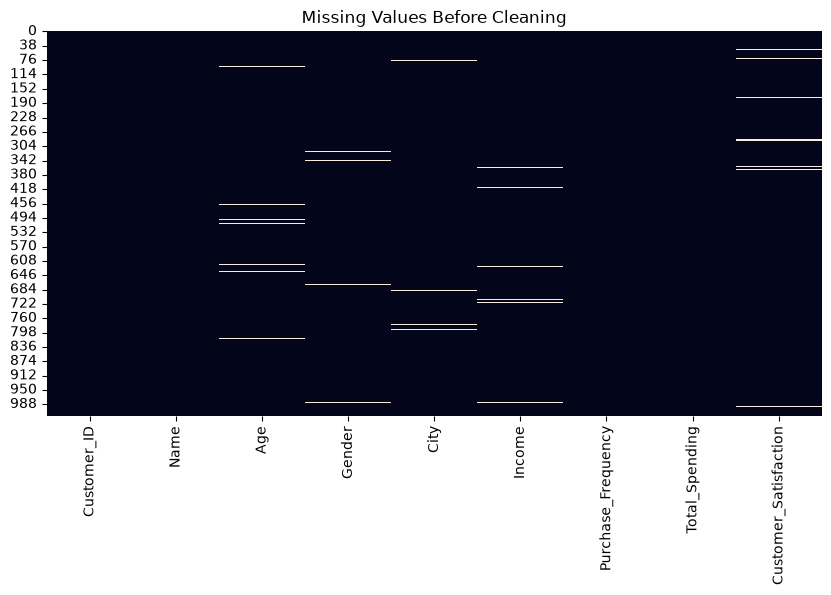


Missing values after treatment:
Customer_ID              0
Name                     0
Age                      0
Gender                   0
City                     0
Income                   0
Purchase_Frequency       0
Total_Spending           0
Customer_Satisfaction    0
dtype: int64

========== DUPLICATE RECORDS ==========
Number of duplicate records: 18
Records after removing duplicates: 1002

========== STANDARDIZING DATA ==========
            Name  Gender       City
0  Karthik Patel  Female    Kolkata
1   Mohan Kapoor  Female    Chennai
2    Suresh Nair    Male      Delhi
3      Mohan Raj    Male  Hyderabad
4    Karthik Das  Female    Kolkata
5   Ramesh Verma    Male     Mumbai
6   Suresh Gupta  Female     Mumbai
7      Nisha Raj  Female    Kolkata
8     Sneha Nair  Female       Pune
9    Nisha Singh  Female    Kolkata

========== DATA TYPES ==========
Customer_ID                int64
Name                         str
Age                      float64
Gender                     

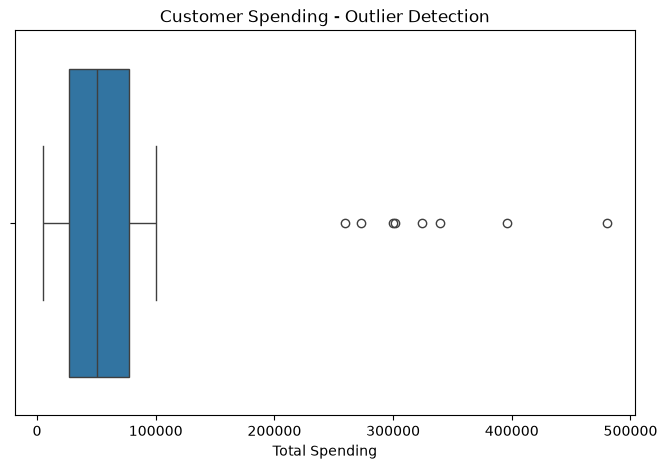


========== FINAL DATA QUALITY CHECK ==========
Missing values:
Customer_ID              0
Name                     0
Age                      0
Gender                   0
City                     0
Income                   0
Purchase_Frequency       0
Total_Spending           0
Customer_Satisfaction    0
dtype: int64

Duplicate records:
1

Final dataset shape:
(976, 9)

Final data:
   Customer_ID           Name   Age  Gender       City     Income  \
0         1001  Karthik Patel  20.0  Female    Kolkata   809351.0   
1         1002   Mohan Kapoor  54.0  Female    Chennai   743216.0   
2         1003    Suresh Nair  60.0    Male      Delhi   932405.0   
3         1004      Mohan Raj  57.0    Male  Hyderabad  1083550.0   
4         1005    Karthik Das  43.0  Female    Kolkata  1383279.0   
5         1006   Ramesh Verma  40.0    Male     Mumbai   745164.0   
6         1007   Suresh Gupta  61.0  Female     Mumbai   539220.0   
7         1008      Nisha Raj  56.0  Female    Kolkata  149445

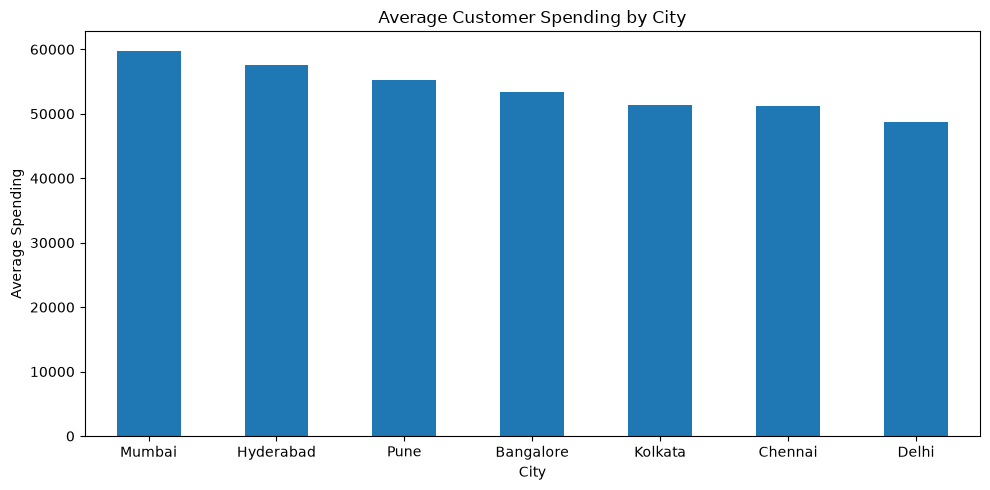


========== CUSTOMER SEGMENTS ==========
      Customer_ID           Name  Total_Spending Customer_Segment
0            1001  Karthik Patel           94524       High Value
1            1002   Mohan Kapoor           86006       High Value
2            1003    Suresh Nair           29704     Medium Value
3            1004      Mohan Raj           99913       High Value
4            1005    Karthik Das           99108       High Value
...           ...            ...             ...              ...
996          1997    Manoj Mehta           55617       High Value
997          1998    Nisha Singh           62473       High Value
998          1999     Pooja Shah           91654       High Value
999          2000    Amit Sharma           93177       High Value
1016         1846    Vikram Shah           34511     Medium Value

[976 rows x 4 columns]

Customer Segment Distribution:
Customer_Segment
High Value      597
Low Value       223
Medium Value    156
Name: count, dtype: int64


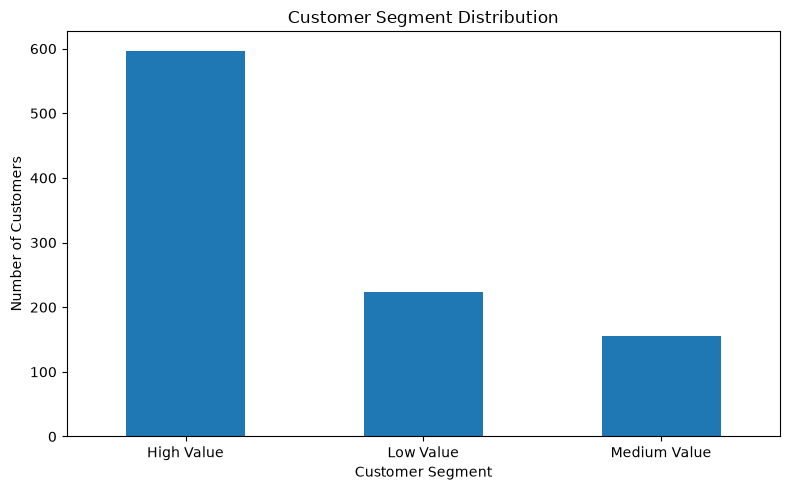


========== PROJECT COMPLETED ==========


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("customer_data.csv")

print("========== ORIGINAL DATA ==========")
print(df.head())

print("\nDataset Shape:")
print(df.shape)
print("\n========== DATA INFORMATION ==========")
print(df.info())

print("\n========== STATISTICAL SUMMARY ==========")
print(df.describe())

print("\n========== MISSING VALUES ==========")

missing = df.isnull().sum()

print(missing)

# Visualize missing values
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Before Cleaning")
plt.show()


# Numerical columns
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Income"] = df["Income"].fillna(df["Income"].median())

df["Customer_Satisfaction"] = df[
    "Customer_Satisfaction"
].fillna(
    df["Customer_Satisfaction"].median()
)

# Categorical columns
df["Gender"] = df["Gender"].fillna(
    df["Gender"].mode()[0]
)

df["City"] = df["City"].fillna(
    df["City"].mode()[0]
)

print("\nMissing values after treatment:")
print(df.isnull().sum())


print("\n========== DUPLICATE RECORDS ==========")

duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

# Remove duplicate records
df = df.drop_duplicates()

print("Records after removing duplicates:", len(df))


print("\n========== STANDARDIZING DATA ==========")

# Remove unnecessary spaces
df["Name"] = df["Name"].str.strip()
df["Gender"] = df["Gender"].str.strip()
df["City"] = df["City"].str.strip()

# Standardize names
df["Name"] = df["Name"].str.title()

# Standardize gender
df["Gender"] = df["Gender"].replace({
    "M": "Male",
    "F": "Female",
    "m": "Male",
    "f": "Female"
})

# Standardize city names
df["City"] = df["City"].str.title()

print(df[["Name", "Gender", "City"]].head(10))

# ------------------------------------------------------------
# 7. CHECK DATA TYPES
# ------------------------------------------------------------

print("\n========== DATA TYPES ==========")

print(df.dtypes)

# Convert numerical columns
df["Age"] = pd.to_numeric(
    df["Age"],
    errors="coerce"
)

df["Income"] = pd.to_numeric(
    df["Income"],
    errors="coerce"
)

df["Purchase_Frequency"] = pd.to_numeric(
    df["Purchase_Frequency"],
    errors="coerce"
)

df["Total_Spending"] = pd.to_numeric(
    df["Total_Spending"],
    errors="coerce"
)

df["Customer_Satisfaction"] = pd.to_numeric(
    df["Customer_Satisfaction"],
    errors="coerce"
)

# ------------------------------------------------------------
# 8. IDENTIFY INVALID AGE VALUES
# ------------------------------------------------------------

print("\n========== INVALID AGE VALUES ==========")

invalid_age = df[
    (df["Age"] < 18) |
    (df["Age"] > 100)
]

print(invalid_age)

# Remove invalid age records
df = df[
    (df["Age"] >= 18) &
    (df["Age"] <= 100)
]


print("\n========== INVALID FINANCIAL VALUES ==========")

invalid_income = df[
    df["Income"] < 0
]

invalid_spending = df[
    df["Total_Spending"] < 0
]

print("Invalid income records:")
print(invalid_income)

print("\nInvalid spending records:")
print(invalid_spending)

# Remove negative values
df = df[df["Income"] >= 0]
df = df[df["Total_Spending"] >= 0]


df = df[
    (df["Customer_Satisfaction"] >= 1) &
    (df["Customer_Satisfaction"] <= 5)
]


print("\n========== OUTLIER DETECTION ==========")

Q1 = df["Total_Spending"].quantile(0.25)

Q3 = df["Total_Spending"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

outliers = df[
    (df["Total_Spending"] < lower_bound) |
    (df["Total_Spending"] > upper_bound)
]

print("\nNumber of spending outliers:",
      len(outliers))

print(outliers)



plt.figure(figsize=(8, 5))

sns.boxplot(
    x=df["Total_Spending"]
)

plt.title("Customer Spending - Outlier Detection")

plt.xlabel("Total Spending")

plt.show()



print("\n========== FINAL DATA QUALITY CHECK ==========")

print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate records:")
print(df.duplicated().sum())

print("\nFinal dataset shape:")
print(df.shape)

print("\nFinal data:")
print(df.head(10))



df.to_csv(
    "cleaned_customer_data.csv",
    index=False
)

print("\nCleaned dataset saved as:")
print("cleaned_customer_data.csv")



print("\n========== BUSINESS ANALYSIS ==========")

# Average spending
average_spending = df["Total_Spending"].mean()

print(
    "Average Customer Spending:",
    round(average_spending, 2)
)

# Highest spending customer
highest_spender = df.loc[
    df["Total_Spending"].idxmax()
]

print("\nHighest Spending Customer:")
print(highest_spender)

# Average spending by city
city_spending = df.groupby(
    "City"
)["Total_Spending"].mean().sort_values(
    ascending=False
)

print("\nAverage Spending by City:")
print(city_spending)

# Average spending by gender
gender_spending = df.groupby(
    "Gender"
)["Total_Spending"].mean()

print("\nAverage Spending by Gender:")
print(gender_spending)



plt.figure(figsize=(10, 5))

city_spending.plot(
    kind="bar"
)

plt.title("Average Customer Spending by City")

plt.xlabel("City")

plt.ylabel("Average Spending")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

def segment_customer(spending):

    if spending >= 40000:
        return "High Value"

    elif spending >= 25000:
        return "Medium Value"

    else:
        return "Low Value"


df["Customer_Segment"] = df[
    "Total_Spending"
].apply(segment_customer)

print("\n========== CUSTOMER SEGMENTS ==========")

print(
    df[
        [
            "Customer_ID",
            "Name",
            "Total_Spending",
            "Customer_Segment"
        ]
    ]
)

# Segment count
segment_count = df[
    "Customer_Segment"
].value_counts()

print("\nCustomer Segment Distribution:")
print(segment_count)



plt.figure(figsize=(8, 5))

segment_count.plot(
    kind="bar"
)

plt.title("Customer Segment Distribution")

plt.xlabel("Customer Segment")

plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

print("\n========== PROJECT COMPLETED ==========")